In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
data_dir = "../data/raw/FracAtlas/images"

fractured_dir = os.path.join(data_dir, "Fractured")
non_fractured_dir = os.path.join(data_dir, "Non_fractured")

csv_path = "../data/raw/FracAtlas/dataset.csv"

In [3]:
fractured_images = os.listdir(fractured_dir)
non_fractured_images = os.listdir(non_fractured_dir)

print("Fractured images:", len(fractured_images))
print("Non-fractured images:", len(non_fractured_images))
print("Total images:", len(fractured_images) + len(non_fractured_images))

Fractured images: 717
Non-fractured images: 3366
Total images: 4083


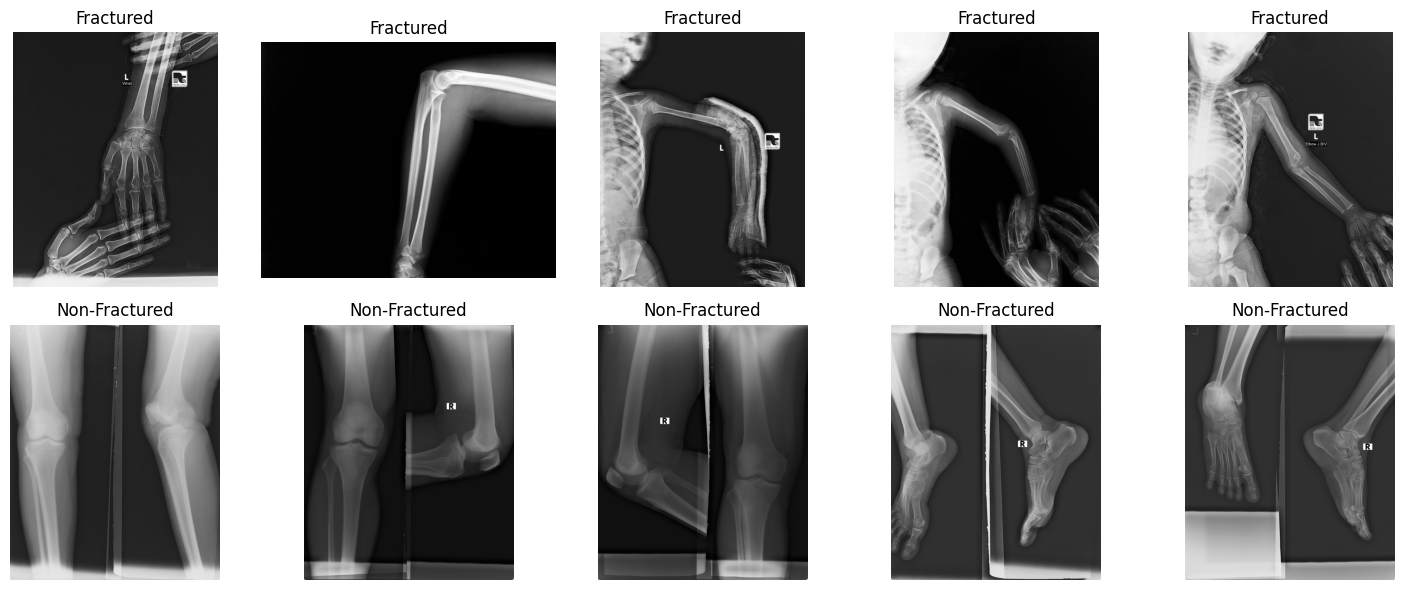

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Fractured
for i, img_name in enumerate(fractured_images[:5]):
    img_path = os.path.join(fractured_dir, img_name)
    img = Image.open(img_path)

    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title("Fractured")
    axes[0, i].axis("off")

# Non-Fractured
for i, img_name in enumerate(non_fractured_images[:5]):
    img_path = os.path.join(non_fractured_dir, img_name)
    img = Image.open(img_path)

    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].set_title("Non-Fractured")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
all_sizes = []

for img_name in fractured_images:
    img_path = os.path.join(fractured_dir, img_name)
    img = Image.open(img_path)
    all_sizes.append(img.size)

for img_name in non_fractured_images:
    img_path = os.path.join(non_fractured_dir, img_name)
    img = Image.open(img_path)
    all_sizes.append(img.size)

unique_sizes = set(all_sizes)

print("Number of unique image sizes:", len(unique_sizes))
print("\nSample sizes:")

for size in list(unique_sizes)[:10]:
    print(size)

Number of unique image sizes: 11

Sample sizes:
(373, 214)
(2880, 2304)
(454, 373)
(1760, 2140)
(373, 454)
(181, 454)
(454, 310)
(1727, 2049)
(2304, 2880)
(296, 454)


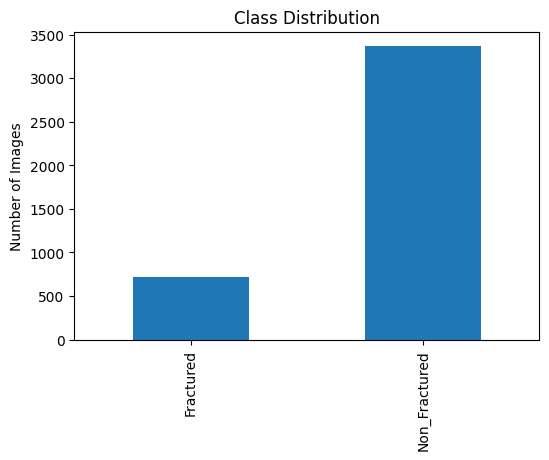

{'Fractured': 717, 'Non_Fractured': 3366}


In [6]:
class_counts = {
    "Fractured": len(fractured_images),
    "Non_Fractured": len(non_fractured_images)
}

pd.Series(class_counts).plot(kind="bar", figsize=(6,4))
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

print(class_counts)

In [7]:
df = pd.read_csv(csv_path)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (4083, 13)

Columns:
['image_id', 'hand', 'leg', 'hip', 'shoulder', 'mixed', 'hardware', 'multiscan', 'fractured', 'fracture_count', 'frontal', 'lateral', 'oblique']


,image_id,hand,leg,hip,shoulder,mixed,hardware,multiscan,fractured,fracture_count,frontal,lateral,oblique
0,IMG0000000.jpg,0,1,0,0,0,0,1,0,0,1,1,0
1,IMG0000001.jpg,0,1,0,0,0,0,1,0,0,1,1,0
2,IMG0000002.jpg,0,1,0,0,0,0,1,0,0,1,1,0
3,IMG0000003.jpg,0,1,0,0,0,0,1,0,0,0,1,1
4,IMG0000004.jpg,0,1,0,0,0,0,1,0,0,0,1,1


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4083 entries, 0 to 4082
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   image_id        4083 non-null   str  
 1   hand            4083 non-null   int64
 2   leg             4083 non-null   int64
 3   hip             4083 non-null   int64
 4   shoulder        4083 non-null   int64
 5   mixed           4083 non-null   int64
 6   hardware        4083 non-null   int64
 7   multiscan       4083 non-null   int64
 8   fractured       4083 non-null   int64
 9   fracture_count  4083 non-null   int64
 10  frontal         4083 non-null   int64
 11  lateral         4083 non-null   int64
 12  oblique         4083 non-null   int64
dtypes: int64(12), str(1)
memory usage: 414.8 KB
